# Maximum Likelihood Estimation

*Given a model, how do we choose its parameters?* We answer it with maximum likelihood,
and show that under a Gaussian noise assumption this leads exactly to squared-error loss —
the loss we had been using all along.

# Part 1 — Model Complexity vs. Test Error (Mall Customers Dataset)

We use the Mall Customers dataset throughout this part. The regression task is:

$$\text{Spending Score} \approx f(\text{Age})$$

Using a single feature keeps everything plottable, so the effect of model complexity is visible
directly on the fitted curve.

## Loading the Mall Customers Dataset

In [1]:
import requests
import os
import pandas as pd

# URL for the raw Mall_Customers.csv file on GitHub
MALL_CUSTOMERS_URL = "https://raw.githubusercontent.com/Sutanoy/Public-Regression-Datasets/main/Mall_Customers.csv"
MALL_CUSTOMERS_FILENAME = "Mall_Customers.csv"

# Create a directory to store the dataset if it doesn't exist
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

file_path = os.path.join(DATA_DIR, MALL_CUSTOMERS_FILENAME)

# Download the dataset
print(f"Downloading dataset from {MALL_CUSTOMERS_URL} to {file_path}...")
response = requests.get(MALL_CUSTOMERS_URL)
response.raise_for_status() # Raise an exception for HTTP errors

with open(file_path, "wb") as f:
    f.write(response.content)

print("Download complete!")
print("Path to Mall Customers CSV file:", file_path)

# Load the Mall_Customers CSV into a pandas DataFrame
df_mall_customers = pd.read_csv(file_path)

# Display the first 5 rows and info to understand the data structure
print("\nFirst 5 rows of the Mall Customers dataset:")
display(df_mall_customers.head())

print("\nDataFrame Info:")
df_mall_customers.info()

Download complete!
Path to Mall Customers CSV file: ./data\Mall_Customers.csv

First 5 rows of the Mall Customers dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Data Visualization: Age vs. Spending Score

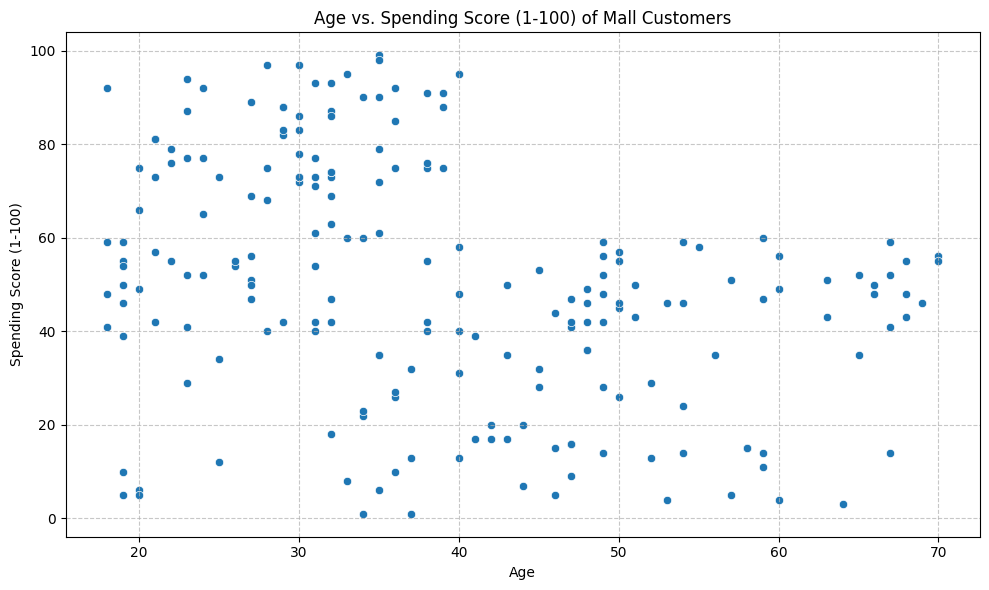

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Age vs. Spending Score
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df_mall_customers)
plt.title('Age vs. Spending Score (1-100) of Mall Customers')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Splitting the Mall Customers Dataset

In [3]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# We'll consider 'Spending Score (1-100)' as the target for a regression task.
# 'CustomerID' is an identifier and should not be used as a feature.
X = df_mall_customers[['Gender', 'Age', 'Annual Income (k$)']]
y = df_mall_customers['Spending Score (1-100)']

# Note: The 'Gender' column is categorical and would need to be one-hot encoded
# before training a machine learning model. This step is usually done during
# feature engineering after the split to avoid data leakage from validation/test sets.

# Split into training (80%) and temporary (20%) datasets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary into training (75% of 80% = 60% of total) and validation (25% of 80% = 20% of total)
# This results in an approximately 60/20/20 split for train/val/test
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Print their lengths to confirm the split sizes
print(f"Length of training features: {len(X_train)}")
print(f"Length of training target: {len(y_train)}")
print(f"Length of validation features: {len(X_val)}")
print(f"Length of validation target: {len(y_val)}")
print(f"Length of test features: {len(X_test)}")
print(f"Length of test target: {len(y_test)}")

print("\nFirst 5 rows of the training features:")
display(X_train.head())
print("\nFirst 5 rows of the training target:")
display(y_train.head())

Length of training features: 120
Length of training target: 120
Length of validation features: 40
Length of validation target: 40
Length of test features: 40
Length of test target: 40

First 5 rows of the training features:


,Gender,Age,Annual Income (k$)
42,Male,48,39
157,Female,30,78
155,Female,27,78
3,Female,23,16
99,Male,20,61



First 5 rows of the training target:


42     36
157    78
155    89
3      77
99     49
Name: Spending Score (1-100), dtype: int64

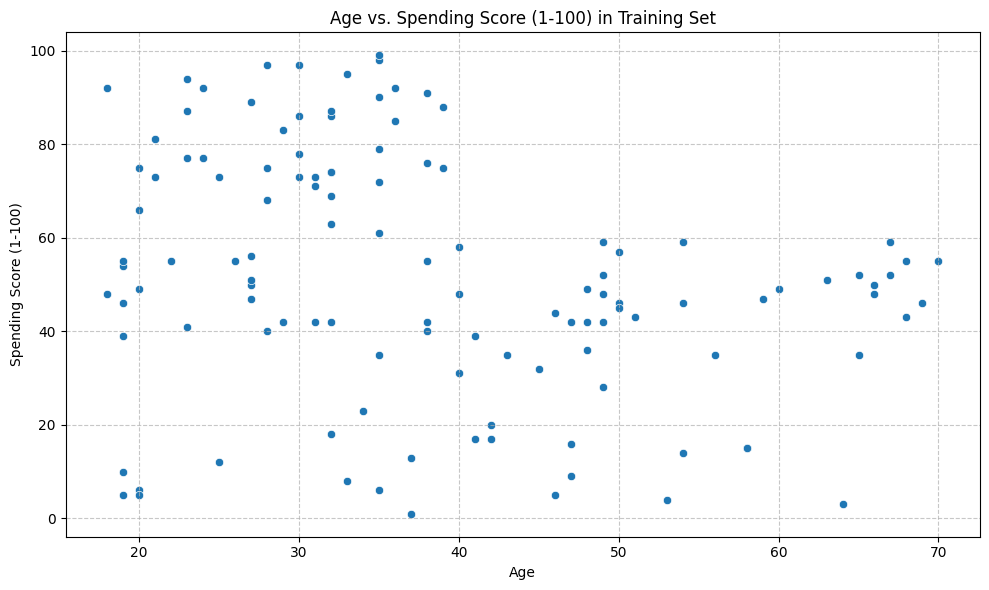

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Age vs. Spending Score for the training set
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['Age'], y=y_train)
plt.title('Age vs. Spending Score (1-100) in Training Set')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Combine X_train, X_val, X_test for consistent one-hot encoding
X_combined = pd.concat([X_train, X_val, X_test], ignore_index=True)

# Perform one-hot encoding on the 'Gender' column
X_combined_encoded = pd.get_dummies(X_combined, columns=['Gender'], drop_first=True, dtype=int)

# Split back into training, validation, and test sets
X_train_encoded = X_combined_encoded.iloc[:len(X_train)]
X_val_encoded = X_combined_encoded.iloc[len(X_train):len(X_train) + len(X_val)]
X_test_encoded = X_combined_encoded.iloc[len(X_train) + len(X_val):]

print("Encoded training features (first 5 rows):")
display(X_train_encoded.head())


Encoded training features (first 5 rows):


,Age,Annual Income (k$),Gender_Male
0,48,39,1
1,30,78,0
2,27,78,0
3,23,16,0
4,20,61,1


# Part 3 — Maximum Likelihood Estimation for Regression

Everything so far has been about **how complex** the model should be:

> How does model complexity affect prediction and generalization?

We now ask a different question, one we quietly skipped:

> **Given a model, how do we choose its parameters?**

Every `LinearRegression().fit(...)` call in this notebook chose parameters by minimizing the sum of
squared errors. Why *squared* errors? Why not absolute errors, or fourth powers?

The answer is that squared-error loss is not an arbitrary choice. It follows from a probabilistic
statement about how the data was generated, through a principle called **maximum likelihood
estimation**. We build it up in two steps: first for a single Gaussian mean, then for regression.

### Step 1: a simple Gaussian example

Forget regression for a moment. Suppose we observe $n$ values $y_1, \dots, y_n$ and model them as
independent draws from a Gaussian with unknown mean $\mu$ and known variance $\sigma^2$:

$$y_i \sim \mathcal{N}(\mu, \sigma^2)$$

The probability density of one observation is

$$p(y_i \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{(y_i - \mu)^2}{2\sigma^2}\right)$$

Because the observations are independent, the density of the whole dataset is the product

$$L(\mu) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{(y_i - \mu)^2}{2\sigma^2}\right)$$

Viewed as a function of $\mu$ with the data held fixed, this is the **likelihood**. Maximum
likelihood estimation picks the $\mu$ that makes the observed data as plausible as possible:

$$\hat{\mu}_{\text{MLE}} = \arg\max_{\mu} L(\mu)$$

Taking logs (which does not move the maximum, since $\log$ is strictly increasing):

$$\log L(\mu) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \mu)^2$$

The first term does not involve $\mu$, and $\sigma^2 > 0$ is fixed, so maximizing $\log L(\mu)$ is
**exactly the same problem** as minimizing

$$\sum_{i=1}^{n}(y_i - \mu)^2$$

Setting the derivative to zero, $-2\sum_i (y_i - \mu) = 0$, gives

$$\hat{\mu}_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

the sample mean. A squared-error objective appeared without anyone choosing it — it fell out of the
Gaussian assumption.

Let us confirm this numerically on the Spending Scores from the Mall Customers training set.

Number of observations           : 120
Sample mean (closed-form MLE)     : 51.7917
Grid search minimum of the NLL    : 51.7917
Grid search minimum of the SSE    : 51.7917
(the grid search can only be as precise as the grid spacing, 0.0100)


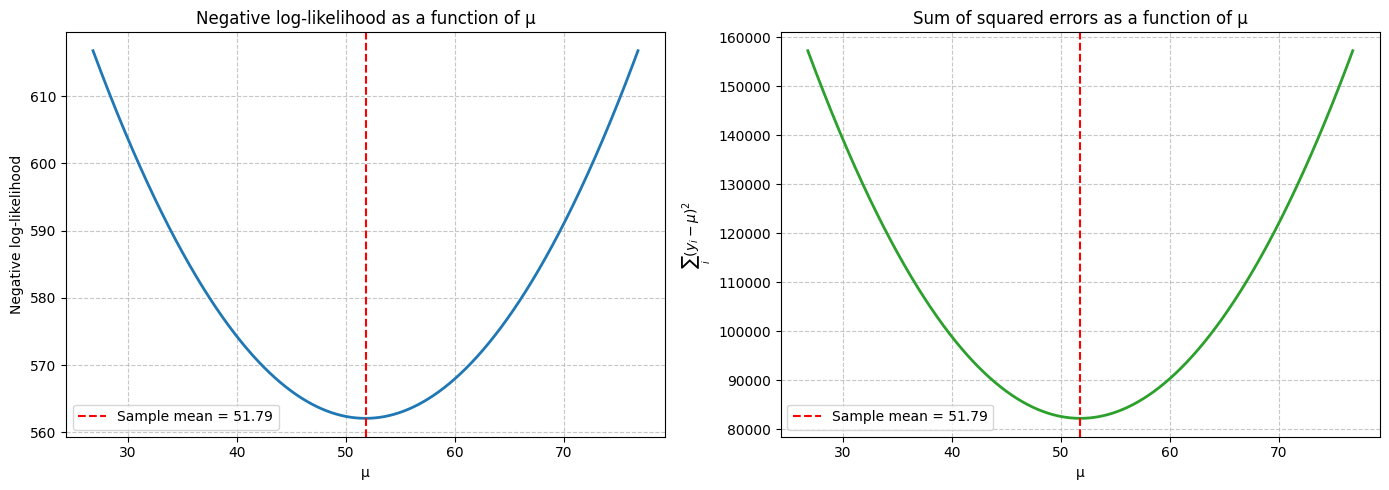

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Observations: the training Spending Scores from Part 1
y_obs = y_train.to_numpy(dtype=float)
n_obs = len(y_obs)

sigma_known = y_obs.std()   # variance treated as known and fixed for this demonstration


def neg_log_likelihood_mu(mu, y, sigma):
    '''Negative log-likelihood of a Gaussian with mean mu and known sigma.'''
    n = len(y)
    return (n / 2) * np.log(2 * np.pi * sigma ** 2) + np.sum((y - mu) ** 2) / (2 * sigma ** 2)


mu_grid = np.linspace(y_obs.mean() - 25, y_obs.mean() + 25, 5001)
nll_values = np.array([neg_log_likelihood_mu(m, y_obs, sigma_known) for m in mu_grid])
sse_values = np.array([np.sum((y_obs - m) ** 2) for m in mu_grid])

mu_grid_best = mu_grid[np.argmin(nll_values)]

print(f"Number of observations           : {n_obs}")
print(f"Sample mean (closed-form MLE)     : {y_obs.mean():.4f}")
print(f"Grid search minimum of the NLL    : {mu_grid_best:.4f}")
print(f"Grid search minimum of the SSE    : {mu_grid[np.argmin(sse_values)]:.4f}")
print(f"(the grid search can only be as precise as the grid spacing, {mu_grid[1] - mu_grid[0]:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mu_grid, nll_values, color='tab:blue', linewidth=2)
axes[0].axvline(y_obs.mean(), color='red', linestyle='--', label=f'Sample mean = {y_obs.mean():.2f}')
axes[0].set_title('Negative log-likelihood as a function of μ')
axes[0].set_xlabel('μ')
axes[0].set_ylabel('Negative log-likelihood')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

axes[1].plot(mu_grid, sse_values, color='tab:green', linewidth=2)
axes[1].axvline(y_obs.mean(), color='red', linestyle='--', label=f'Sample mean = {y_obs.mean():.2f}')
axes[1].set_title('Sum of squared errors as a function of μ')
axes[1].set_xlabel('μ')
axes[1].set_ylabel(r'$\sum_i (y_i - \mu)^2$')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

The two curves are the same shape up to a positive scale factor and an additive constant, so they
have the same minimizer. That is the whole point.

### Probability vs likelihood

These are the same formula read in two different directions, and mixing them up causes endless
confusion.

**Probability.** Parameters are fixed, data varies. We ask: *given $\mu$ and $\sigma^2$, how likely is
it that we observe values like these?* Integrating over all possible datasets gives 1.

**Likelihood.** The data is fixed (we already observed it), parameters vary. We ask: *which value of
$\mu$ makes the data we actually saw most plausible?*

An important consequence: the likelihood function is **not a probability distribution over the
parameter**. $L(\mu)$ does not integrate to 1 over $\mu$, and $L(\mu_1) = 2 L(\mu_2)$ does not mean
$\mu_1$ is "twice as probable". It means the data is twice as plausible under $\mu_1$ as under
$\mu_2$. Turning likelihood into a distribution over parameters requires a prior and Bayes' rule,
which is a different topic.

### Step 2: maximum likelihood for linear regression

Now put the features back in. The model is

$$y_i = \mathbf{x}_i^\top \mathbf{w} + b + \epsilon_i,
\qquad \epsilon_i \sim \mathcal{N}(0, \sigma^2) \ \text{ i.i.d.}$$

Writing the prediction as

$$\hat{y}_i = \mathbf{x}_i^\top \mathbf{w} + b$$

the noise assumption says that, conditional on the input, the target is Gaussian around the prediction:

$$y_i \mid \mathbf{x}_i \sim \mathcal{N}(\hat{y}_i, \sigma^2)$$

So the conditional density of one observation is

$$p(y_i \mid \mathbf{x}_i, \mathbf{w}, b, \sigma^2)
= \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - \hat{y}_i)^2}{2\sigma^2}\right)$$

and, assuming the observations are independent, the likelihood of the whole dataset is

$$L(\mathbf{w}, b, \sigma^2)
= \prod_{i=1}^{n} p(y_i \mid \mathbf{x}_i, \mathbf{w}, b, \sigma^2)
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{(y_i - \hat{y}_i)^2}{2\sigma^2}\right)$$

**Maximum likelihood estimation chooses the regression parameters $\mathbf{w}$ and $b$ that maximize
the likelihood of the observed target values.**

#### Why take the logarithm?

Three reasons, all practical:

1. Products become sums, which are far easier to differentiate.
2. A product of $n$ small densities underflows to zero in floating point; a sum of logs does not.
3. $\log$ is strictly increasing, so $\arg\max L = \arg\max \log L$. Nothing is lost.

The log-likelihood is

$$\log L(\mathbf{w}, b, \sigma^2)
= -\frac{n}{2}\log(2\pi\sigma^2)
- \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

#### The connection

For a **fixed** $\sigma^2$, the first term is a constant with respect to $\mathbf{w}$ and $b$, and
$\frac{1}{2\sigma^2}$ is a positive constant multiplying the sum. Therefore

$$\arg\max_{\mathbf{w},\, b} \log L
\;=\;
\arg\min_{\mathbf{w},\, b} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

which is ordinary least squares — the objective `LinearRegression` has been minimizing all along.

If we also maximize over $\sigma^2$, differentiating the log-likelihood gives

$$\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

the mean squared residual. (This is the biased estimator of the noise variance; the unbiased version
divides by $n - p$ instead. MLE does not promise unbiasedness.)

The cell below checks all of this numerically on the Age → Spending Score model from Part 1: it
maximizes the Gaussian log-likelihood over $(w, b)$ with a numerical optimizer that knows nothing
about least squares, and compares the result with what `LinearRegression` returns.

One detail worth noticing in the contour plot: the log-likelihood surface is a long diagonal ridge
rather than a circular bowl. That is because Age is not centered — raising the slope can be
compensated by lowering the intercept, so many $(w, b)$ pairs explain the data almost equally well.
The maximum is still unique, but the data constrains some directions in parameter space far more
tightly than others.

Ordinary least squares (sklearn)
  slope w      : -0.499073
  intercept b  : 70.918633
  sigma^2 MLE  : 635.3706   (mean squared residual)

Maximum likelihood, found numerically (sigma^2 fixed)
  slope w      : -0.499073   (OLS: -0.499073)
  intercept b  : 70.918633   (OLS: 70.918633)
  max log-likelihood                : -557.525135
  log-likelihood at the OLS solution: -557.525135


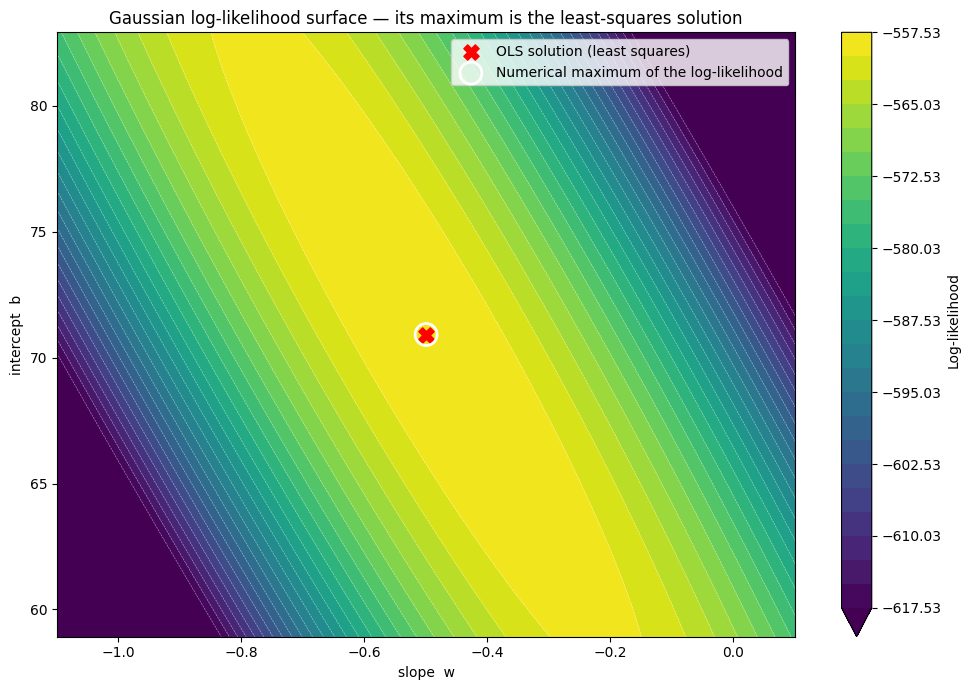

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# The simple Age-only model from Part 1
X_train_age = X_train[['Age']]
x_mle = X_train_age['Age'].to_numpy(dtype=float)
y_mle = y_train.to_numpy(dtype=float)
n_mle = len(y_mle)

# 1. Ordinary least squares fit (what sklearn does)
ols = LinearRegression().fit(x_mle.reshape(-1, 1), y_mle)
w_ols, b_ols = ols.coef_[0], ols.intercept_

residuals = y_mle - ols.predict(x_mle.reshape(-1, 1))
sigma2_mle = np.mean(residuals ** 2)

print("Ordinary least squares (sklearn)")
print(f"  slope w      : {w_ols:.6f}")
print(f"  intercept b  : {b_ols:.6f}")
print(f"  sigma^2 MLE  : {sigma2_mle:.4f}   (mean squared residual)")


def log_likelihood(w, b, sigma2):
    '''Gaussian log-likelihood of the training targets under the linear model.'''
    y_hat = w * x_mle + b
    return (-n_mle / 2 * np.log(2 * np.pi * sigma2)
            - np.sum((y_mle - y_hat) ** 2) / (2 * sigma2))


# 2. Maximize the log-likelihood over a grid of (w, b), with sigma^2 held fixed
w_range = np.linspace(w_ols - 0.6, w_ols + 0.6, 241)
b_range = np.linspace(b_ols - 12, b_ols + 12, 241)
W, B = np.meshgrid(w_range, b_range)

LL = np.array([[log_likelihood(w, b, sigma2_mle) for w in w_range] for b in b_range])

i_best, j_best = np.unravel_index(np.argmax(LL), LL.shape)
w_grid_best, b_grid_best = w_range[j_best], b_range[i_best]

# 2b. Maximize the log-likelihood numerically, with no grid involved at all
from scipy.optimize import minimize
opt = minimize(lambda p: -log_likelihood(p[0], p[1], sigma2_mle), x0=[0.0, 0.0], method='Nelder-Mead',
               options={'xatol': 1e-8, 'fatol': 1e-10, 'maxiter': 20000})
w_opt, b_opt = opt.x

print("\nMaximum likelihood, found numerically (sigma^2 fixed)")
print(f"  slope w      : {w_opt:.6f}   (OLS: {w_ols:.6f})")
print(f"  intercept b  : {b_opt:.6f}   (OLS: {b_ols:.6f})")
print(f"  max log-likelihood                : {-opt.fun:.6f}")
print(f"  log-likelihood at the OLS solution: {log_likelihood(w_ols, b_ols, sigma2_mle):.6f}")

# 3. Contour plot of the log-likelihood surface with the OLS solution marked
plt.figure(figsize=(10, 7))
levels = np.linspace(LL.max() - 60, LL.max(), 25)
cs = plt.contourf(W, B, LL, levels=levels, cmap='viridis', extend='min')
plt.contour(W, B, LL, levels=levels, colors='white', linewidths=0.4, alpha=0.6)
plt.colorbar(cs, label='Log-likelihood')
plt.scatter([w_ols], [b_ols], color='red', s=120, marker='X',
            label='OLS solution (least squares)', zorder=5)
plt.scatter([w_opt], [b_opt], facecolors='none', edgecolors='white', s=250,
            linewidths=2, label='Numerical maximum of the log-likelihood', zorder=5)
plt.xlabel('slope  w')
plt.ylabel('intercept  b')
plt.title('Gaussian log-likelihood surface — its maximum is the least-squares solution')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

argmin of the negative log-likelihood : w = -0.499073
argmin of the sum of squared errors   : w = -0.499073
sklearn's OLS slope                   : w = -0.499073
(grid spacing on this slice: 0.000500)

Max |NLL(w) - [const + SSE(w)/(2 sigma^2)]| over the slice: 0.0000000000


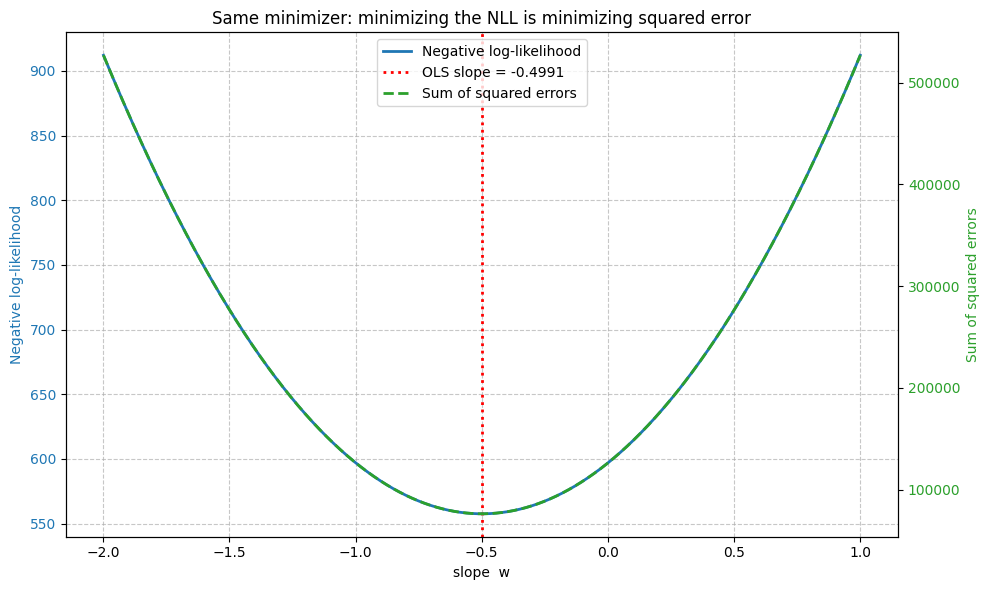

In [9]:
# One-dimensional slice: vary the slope with the intercept fixed at its OLS value.
# The negative log-likelihood and the sum of squared errors are minimized at the same w.
w_slice = np.linspace(w_ols - 1.5, w_ols + 1.5, 6001)

nll_slice = np.array([-log_likelihood(w, b_ols, sigma2_mle) for w in w_slice])
sse_slice = np.array([np.sum((y_mle - (w * x_mle + b_ols)) ** 2) for w in w_slice])

print(f"argmin of the negative log-likelihood : w = {w_slice[np.argmin(nll_slice)]:.6f}")
print(f"argmin of the sum of squared errors   : w = {w_slice[np.argmin(sse_slice)]:.6f}")
print(f"sklearn's OLS slope                   : w = {w_ols:.6f}")
print(f"(grid spacing on this slice: {w_slice[1] - w_slice[0]:.6f})")

# The two objectives differ only by the positive factor 1/(2 sigma^2) and an additive constant:
#     NLL(w) = const + SSE(w) / (2 sigma^2)
reconstructed = (n_mle / 2) * np.log(2 * np.pi * sigma2_mle) + sse_slice / (2 * sigma2_mle)
print(f"\nMax |NLL(w) - [const + SSE(w)/(2 sigma^2)]| over the slice: "
      f"{np.max(np.abs(nll_slice - reconstructed)):.10f}")

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(w_slice, nll_slice, color='tab:blue', linewidth=2, label='Negative log-likelihood')
ax1.set_xlabel('slope  w')
ax1.set_ylabel('Negative log-likelihood', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(w_slice, sse_slice, color='tab:green', linewidth=2, linestyle='--',
         label='Sum of squared errors')
ax2.set_ylabel('Sum of squared errors', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.axvline(w_ols, color='red', linestyle=':', linewidth=2, label=f'OLS slope = {w_ols:.4f}')
ax1.set_title('Same minimizer: minimizing the NLL is minimizing squared error')
ax1.grid(True, linestyle='--', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

plt.tight_layout()
plt.show()

### The chain, in one place

```
Gaussian noise assumption:  y_i | x_i  ~  N(x_i·w + b, σ²)
        ↓
Maximum likelihood estimation
        ↓
Maximize the likelihood            ∏ᵢ p(yᵢ | xᵢ, w, b, σ²)
        ↓
Maximize the log-likelihood        −(n/2)log(2πσ²) − (1/2σ²) Σᵢ (yᵢ − ŷᵢ)²
        ↓
Minimize the negative log-likelihood
        ↓
Minimize squared-error loss        Σᵢ (yᵢ − ŷᵢ)²
        ↓
Ordinary least squares regression
```

**Squared-error loss is not an arbitrary choice in this setting.** It arises naturally as the
negative log-likelihood under a Gaussian noise assumption, up to an additive constant and a positive
scale factor — neither of which affects where the minimum is.

Be precise about the conditions under which the equivalence holds:

* The noise is **Gaussian**. A different noise model gives a different loss. Laplace noise, for
  instance, yields absolute-error loss; a Bernoulli likelihood yields cross-entropy.
* The noise terms are **independent** across observations. That is what turns the joint density into
  a product, and the log-likelihood into a sum.
* The noise variance $\sigma^2$ is **constant** across observations (homoscedastic) and treated as
  fixed while optimizing $\mathbf{w}$ and $b$. With per-observation variances $\sigma_i^2$, the same
  derivation gives *weighted* least squares, with weights $1/\sigma_i^2$.

If those assumptions do not describe your data, least squares may still be a reasonable choice — but
it no longer has this particular justification.

### Back to Bias and Variance: Why likelihood alone cannot choose complexity

Recall the log-likelihood values printed alongside the polynomial fits in Part 1. Now we know exactly
what that formula was. Substituting $\hat{\sigma}^2_{\text{MLE}} = \text{MSE}$ back into the
log-likelihood gives its maximized value:

$$\log L_{\max} = -\frac{n}{2}\Big(\log(2\pi) + \log \widehat{\sigma}^2_{\text{MLE}} + 1\Big)$$

This is a strictly decreasing function of the training MSE. And training MSE never increases as we
add polynomial terms. So the **training log-likelihood can only go up with complexity** — which
means it can never, on its own, tell us to stop.

This is the Part 1 lesson restated in likelihood language: maximum likelihood is an excellent answer
to *"given this model, which parameters?"* and no answer at all to *"which model?"*. Choosing
complexity needs held-out data (test/validation error), or a criterion that penalizes parameter
count (AIC, BIC), or regularization. The cell below makes the point concrete.

In [10]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

print(f"{'Degree':>8} {'Train MSE':>12} {'Train logL':>14} {'Test MSE':>12} {'Test logL':>14}")
complexity_orders = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20]
X_test_age = X_test[['Age']]

for order in complexity_orders:
    model_poly = make_pipeline(
        MinMaxScaler(feature_range=(-1, 1)),
        PolynomialFeatures(degree=order),
        LinearRegression()
    )
    model_poly.fit(X_train_age, y_train)

    mse_tr = mean_squared_error(y_train, model_poly.predict(X_train_age))
    mse_te = mean_squared_error(y_test, model_poly.predict(X_test_age))

    # Maximized training log-likelihood, using sigma^2_MLE = training MSE
    n_tr = len(y_train)
    logL_tr = -(n_tr / 2) * (np.log(2 * np.pi) + np.log(mse_tr) + 1)

    # Log-likelihood of the *test* targets under the same fitted model and the same sigma^2
    n_te = len(y_test)
    logL_te = (-(n_te / 2) * np.log(2 * np.pi * mse_tr)
               - (n_te * mse_te) / (2 * mse_tr))

    print(f"{order:>8} {mse_tr:>12.2f} {logL_tr:>14.2f} {mse_te:>12.2f} {logL_te:>14.2f}")

print("\nTraining log-likelihood rises monotonically with complexity;")
print("test log-likelihood does not. Held-out data is what tells us when to stop.")

  Degree    Train MSE     Train logL     Test MSE      Test logL
       1       635.37        -557.53       467.74        -180.57
       2       635.33        -557.52       465.56        -180.50
       3       553.05        -549.20       406.25        -177.76
       4       545.50        -548.37       419.83        -178.18
       6       542.69        -548.06       413.09        -177.91
       8       539.83        -547.75       395.37        -177.23
      10       510.07        -544.35       453.09        -179.21
      12       502.61        -543.46       473.21        -179.98
      15       470.79        -539.54       487.01        -180.54
      20       459.67        -538.10       460.56        -179.41

Training log-likelihood rises monotonically with complexity;
test log-likelihood does not. Held-out data is what tells us when to stop.
